In [ ]:
import random

In [ ]:
import numpy as np

# Randomly distribute K into list containing N integers
K = 100
N = 20

ls = [0 for _ in range(20)]
for _ in range(100):
    ls[random.randint(0, N-1)] += 1
ls, sum(ls)

([6, 6, 8, 4, 4, 4, 5, 8, 4, 4, 5, 3, 3, 2, 2, 4, 8, 8, 7, 5], 100)

In [ ]:
from itertools import product

def letterCombinations(digits):
    letters_d = {'2': 'a b c', '3': 'd e f', '4': 'g h i', '5': 'j k l', '6': 'm n o', '7': 'p q r s', '8': 't u v', '9': 'w x y z'}
    digits = str(digits)
    res = []
    if len(digits) == 0:
        return res
    else:
        return [''.join(i) for i in list(product(*[letters_d[i].split(' ') for i in digits]))]

letterCombinations("23")

['ad', 'ae', 'af', 'bd', 'be', 'bf', 'cd', 'ce', 'cf']

In [ ]:
digits = "23"

letters_d = {'2': 'a b c', '3': 'd e f', '4': 'g h i', '5': 'j k l', '6': 'm n o', '7': 'p q r s', '8': 't u v', '9': 'w x y z'}
    
[letters_d[i].split(' ') for i in digits]

[['a', 'b', 'c'], ['d', 'e', 'f']]

In [ ]:
list(product(*[letters_d[i].split(' ') for i in digits]))

[('a', 'd'),
 ('a', 'e'),
 ('a', 'f'),
 ('b', 'd'),
 ('b', 'e'),
 ('b', 'f'),
 ('c', 'd'),
 ('c', 'e'),
 ('c', 'f')]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors

# 参数设置
n_samples = 800  # 样本数量（减少数量加快计算）
k_neighbors = 6   # 每个点的邻居数量
noise_level = 0.1 # 数据噪声强度

# 1. 生成瑞士卷数据[1,3,4](@ref)
X, color = make_swiss_roll(n_samples=n_samples, noise=noise_level, random_state=42)

# 2. 计算kNN邻居关系[6,8](@ref)
nbrs = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm='ball_tree').fit(X)
distances, indices = nbrs.kneighbors(X)  # 包含自身点的索引


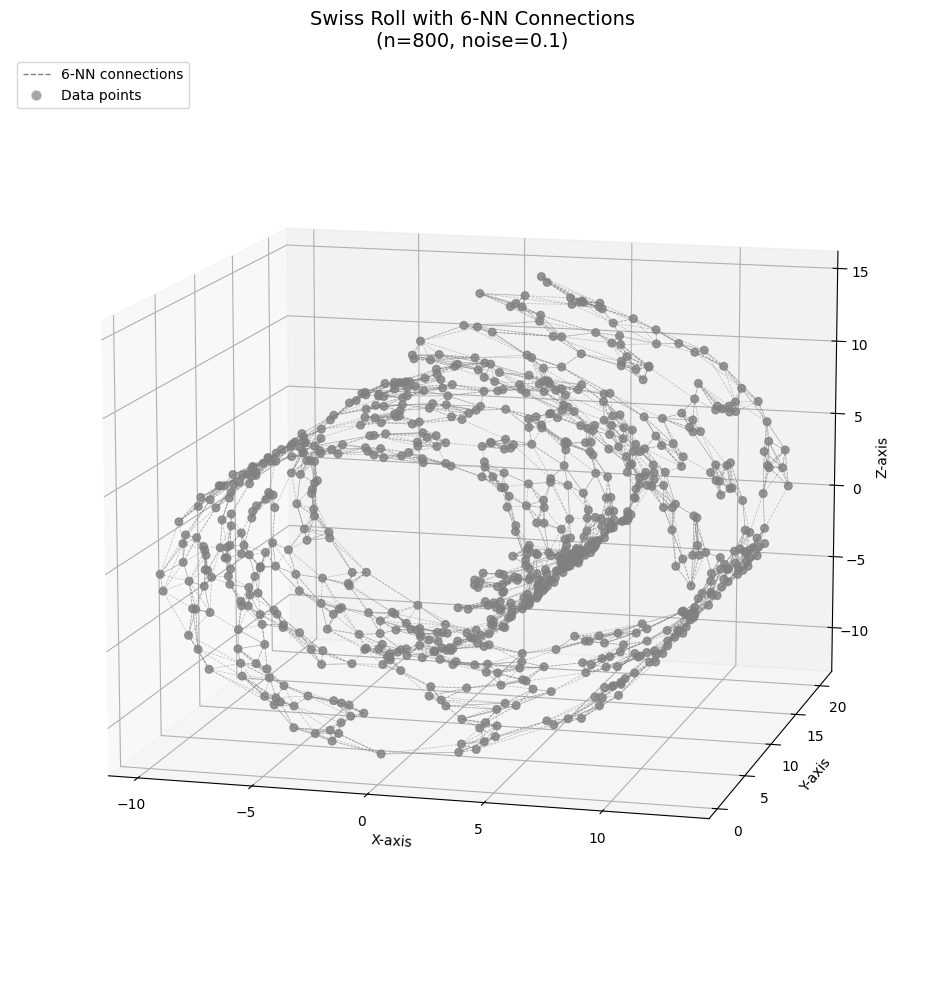

In [ ]:

# 3. 可视化设置
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# 4. 绘制原始数据点[4](@ref)
scatter = ax.scatter(X[:,0], X[:,1], X[:,2], c="gray",
                    s=30, alpha=0.8,
                    label='Data points')

# 5. 绘制kNN连接线[8](@ref)
for i in range(len(X)):
    # 排除自身的k个最近邻
    neighbors = indices[i][1:] 
    
    # 绘制每个邻居的连线
    for neighbor in neighbors:
        line = np.array([X[i], X[neighbor]])
        ax.plot(line[:,0], line[:,1], line[:,2],
                color='gray', alpha=0.5, 
                linewidth=0.5, linestyle='--')

# 6. 可视化优化
ax.view_init(elev=12, azim=-75)  # 最佳观察角度[4](@ref)
ax.set_title(f"Swiss Roll with {k_neighbors}-NN Connections\n"
            f"(n={n_samples}, noise={noise_level})", fontsize=14)
ax.set_xlabel('X-axis', fontsize=10)
ax.set_ylabel('Y-axis', fontsize=10)
ax.set_zlabel('Z-axis', fontsize=10)

# 添加图例元素
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', lw=1, linestyle='--', 
          label=f'{k_neighbors}-NN connections'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
          markersize=8, alpha=0.7, label='Data points')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import networkx as nx
from GraphRicciCurvature.OllivierRicci import OllivierRicci

# 参数设置
n_samples = 300    # 减少样本量加速曲率计算
k_neighbors = 5     # 每个点的邻居数量
top_edges = 20      # 显示曲率最低的边数量

# 1. 生成瑞士卷数据
X, color = make_swiss_roll(n_samples=n_samples, noise=0.1, random_state=42)

# 2. 构建kNN图
nbrs = NearestNeighbors(n_neighbors=k_neighbors+1).fit(X)
_, indices = nbrs.kneighbors(X)
G = nx.Graph()
for i in range(len(X)):
    for j in indices[i][1:]:  # 排除自身
        G.add_edge(i, j)

# 3. 计算Ollivier-Ricci曲率
orc = OllivierRicci(G, alpha=0.5, verbose="INFO")
orc.compute_ricci_curvature()
edge_curvatures = [(edge, data["ricciCurvature"]) for edge, data in orc.G.edges.items()]

# 4. 获取曲率最低的边
sorted_edges = sorted(edge_curvatures, key=lambda x: x[1])[:top_edges]
critical_edges = [edge for edge, _ in sorted_edges]

# 3. 计算Ollivier-Ricci曲率
orc = OllivierRicci(G, alpha=0.5, verbose="INFO")
orc.compute_ricci_curvature()
edge_curvatures = [(edge, data["ricciCurvature"]) for edge, data in orc.G.edges.items()]

# 4. 获取曲率最低的边
sorted_edges = sorted(edge_curvatures, key=lambda x: x[1])[:top_edges]
critical_edges = [edge for edge, _ in sorted_edges]

# 5. 可视化设置
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制普通点（灰色）
ax.scatter(X[:,0], X[:,1], X[:,2], 
          c='gray', alpha=0.6,
          s=20, depthshade=True)

# 绘制关键点（红色）和连接线
critical_nodes = set()
for (u, v) in critical_edges:
    critical_nodes.add(u)
    critical_nodes.add(v)
    line = np.array([X[u], X[v]])
    ax.plot(line[:,0], line[:,1], line[:,2], 
            color='red', alpha=0.9, 
            linewidth=1.5)

# 高亮关键节点
ax.scatter(X[list(critical_nodes),0], 
          X[list(critical_nodes),1],
          X[list(critical_nodes),2], 
          c='red', alpha=0.9,
          s=40, edgecolors='k')

# 绘制普通连接线（细黑线）
for i in range(len(X)):
    for j in indices[i][1:]:
        if (i,j) not in critical_edges and (j,i) not in critical_edges:
            line = np.array([X[i], X[j]])
            ax.plot(line[:,0], line[:,1], line[:,2],
                    color='black', alpha=0.15,
                    linewidth=0.3)

# 可视化优化
ax.view_init(elev=15, azim=-70)
ax.set_title(f"Swiss Roll with {k_neighbors}-NN Connections\n"
            f"Critical Edges (Lowest {top_edges} Ollivier-Ricci Curvatures)", 
            fontsize=12)
plt.tight_layout()
plt.show()

ValueError: cannot find context for 'fork'

In [5]:
import numpy as np

my_res = np.array(
    [
  [0.51647, 0.56978, 0.61068, 0.61539, 0.64654, 0.76342, 0.80786, 0.81896, 0.78116, 0.88025, 0.92331, 0.93434, 2.22236, 2.43125, 2.59491, 2.61149],
  [0.51733, 0.5988, 0.62868, 0.62631, 0.65736, 0.80674, 0.81915, 0.81624, 0.77517, 0.93814, 0.94812, 0.92805, 2.22145, 2.51933, 2.59726, 2.5715],
  [0.52367, 0.59015, 0.61529, 0.61895, 0.664, 0.77975, 0.77682, 0.8, 0.77517, 0.91068, 0.92021, 0.95084, 2.23969, 2.49234, 2.57546, 2.59467],
  [0.5211, 0.56171, 0.61018, 0.60818, 0.6652, 0.73691, 0.81379, 0.81145, 0.77432, 0.86913, 0.95536, 0.94454, 2.21975, 2.36919, 2.67772, 2.65736],
  [0.51964, 0.59112, 0.60365, 0.59818, 0.66863, 0.78196, 0.77202, 0.76443, 0.77919, 0.90038, 0.89469, 0.88573, 2.23068, 2.49418, 2.5576, 2.52342]
]
)
print(my_res.shape)
my_res = my_res.T.min(axis=-1)

(5, 16)


In [4]:
my_res.shape

(16,)

In [6]:
lower_bound = [449.62,  403.22,  394.02,  390.75 , 594.66,  560.8 ,  559.26  ,554.08 , 835.53,
  780.92 , 765.62  ,756.16,  975.84 , 922.84 , 919.77  ,902.65,2003.33 ,1926.4,
 1840.03 ,1861.78]

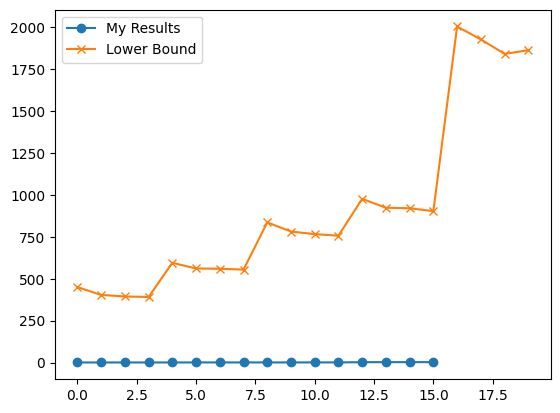

In [8]:
import matplotlib.pyplot as plt

plt.plot(my_res, label='My Results', marker='o')
plt.plot(lower_bound, label='Lower Bound', marker='x')
plt.legend()